<a href="https://colab.research.google.com/github/stephen-njiu/10Xfocus/blob/main/AI_Project_5_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Get all imports
import numpy as np
import pandas as pd
# from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, InputLayer
# from tensorflow.keras.layers import GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
import matplotlib.pyplot as plt
import os
import zipfile
import urllib.request

In [7]:
# Define the URL and the target path
url = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip'
zip_path = 'jena_climate_2009_2016.csv.zip'
csv_path = 'jena_climate_2009_2016.csv'

# Download the zip file
urllib.request.urlretrieve(url, zip_path)

# Extract the CSV file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

# Check if the file is extracted
if os.path.exists(csv_path):
    print(f"Dataset extracted: {csv_path}")
else:
    print("Something went wrong during extraction.")

Dataset extracted: jena_climate_2009_2016.csv


In [8]:
df = pd.read_csv(csv_path, parse_dates=['Date Time'], index_col = 'Date Time')
df

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2


In [9]:
df.describe(include='all')

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,989.212776,9.450147,283.492743,4.955854,76.008259,13.576251,9.533756,4.042412,6.022408,9.640223,1216.062748,1.702224,3.056555,174.743738
std,8.358481,8.423365,8.504471,6.730674,16.476175,7.739020,4.184164,4.896851,2.656139,4.235395,39.975208,65.446714,69.016932,86.681693
min,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,-9999.000000,-9999.000000,0.000000
25%,984.200000,3.360000,277.430000,0.240000,65.210000,7.780000,6.210000,0.870000,3.920000,6.290000,1187.490000,0.990000,1.760000,124.900000
50%,989.580000,9.420000,283.470000,5.220000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.790000,1.760000,2.960000,198.100000
75%,994.720000,15.470000,289.530000,10.070000,89.400000,17.600000,12.350000,5.300000,7.800000,12.490000,1242.770000,2.860000,4.740000,234.100000
max,1015.350000,37.280000,311.340000,23.110000,100.000000,63.770000,28.320000,46.010000,18.130000,28.820000,1393.540000,28.490000,23.500000,360.000000


In [10]:
df.info() # no missing values, data is ok...

<class 'pandas.core.frame.DataFrame'>
Index: 420551 entries, 01.01.2009 00:10:00 to 01.01.2017 00:00:00
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   p (mbar)         420551 non-null  float64
 1   T (degC)         420551 non-null  float64
 2   Tpot (K)         420551 non-null  float64
 3   Tdew (degC)      420551 non-null  float64
 4   rh (%)           420551 non-null  float64
 5   VPmax (mbar)     420551 non-null  float64
 6   VPact (mbar)     420551 non-null  float64
 7   VPdef (mbar)     420551 non-null  float64
 8   sh (g/kg)        420551 non-null  float64
 9   H2OC (mmol/mol)  420551 non-null  float64
 10  rho (g/m**3)     420551 non-null  float64
 11  wv (m/s)         420551 non-null  float64
 12  max. wv (m/s)    420551 non-null  float64
 13  wd (deg)         420551 non-null  float64
dtypes: float64(14)
memory usage: 48.1+ MB


In [11]:
df = df[300000:]# iloc df.iloc[start:end] # slicing some data
df

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
13.09.2014 02:20:00,993.16,14.78,288.51,14.59,98.80,16.84,16.64,0.20,10.49,16.75,1193.96,2.49,4.04,26.06
13.09.2014 02:30:00,993.17,14.73,288.45,14.56,98.90,16.78,16.60,0.18,10.46,16.71,1194.19,2.58,4.14,28.76
13.09.2014 02:40:00,993.25,14.73,288.45,14.56,98.90,16.78,16.60,0.18,10.46,16.71,1194.29,2.08,2.80,25.65
13.09.2014 02:50:00,993.30,14.73,288.44,14.56,98.90,16.78,16.60,0.18,10.46,16.71,1194.34,2.41,3.24,27.59
13.09.2014 03:00:00,993.29,14.73,288.44,14.56,98.90,16.78,16.60,0.18,10.46,16.71,1194.34,2.13,3.48,27.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.00
31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.30
31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.20


# **Prepare the data**
- Create sequences, defined by a length of user input param `sequence_length`, scale the data and return training data, testing data, and the scaler


In [12]:
def prepare_data(df, sequence_length):
    # Extract temperature data and convert to numpy array
    data = df['T (degC)'].values.reshape(-1, 1) # one to one LSTM, many to one, and many to many

    # Normalize the data
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)

    # Create sequences
    X, y = [], []
    for i in range(len(scaled_data) - sequence_length):
        X.append(scaled_data[i:i+sequence_length])
        y.append(scaled_data[i+sequence_length])

    X = np.array(X)
    y = np.array(y)

    # Split into train and test sets
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    return X_train, X_test, y_train, y_test, scaler

In [13]:
X_train, X_test, y_train, y_test, scaler = prepare_data(df, sequence_length=6) # 6*10
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((96436, 6, 1), (24109, 6, 1), (96436, 1), (24109, 1))

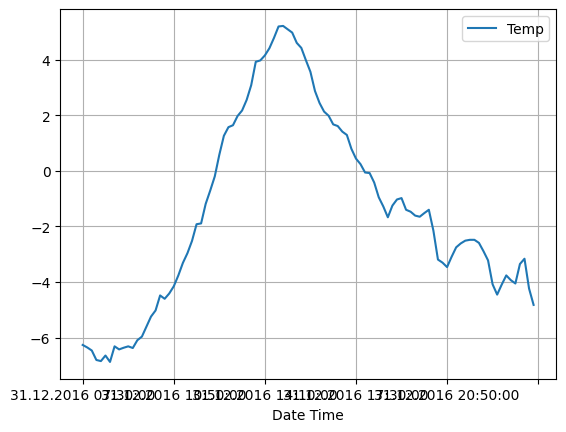

In [14]:
df['T (degC)'][-100:].plot(label = 'Temp')
plt.legend()
plt.grid()
plt.show()

In [15]:
def create_model(sequence_length):
    model = Sequential()
    input_shape = (sequence_length, 1) # sequence, no_of_parameters
    # Define the input layer explicitly
    model.add(InputLayer(input_shape))

    # First LSTM layer with Dropout to prevent overfitting
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.2))# to prevent overfitting and to generalize better on unseen data

    # Second LSTM layer
    model.add(LSTM(units=32, return_sequences=False))

    # model.add(LSTM(units = 16))
    # Dense layer for output
    model.add(Dense(1)) # activation functions like f(x) = x, max(0,x)# relu

    # Compile the model
    model.compile(optimizer='adam', loss='mse')

    return model

In [16]:
def make_future_predictions(model, last_sequence, n_steps, scaler):
    future_predictions = []
    current_sequence = last_sequence.copy()

    for _ in range(n_steps):
        # Get the prediction
        current_pred = model.predict(current_sequence)

        # Append prediction
        future_predictions.append(current_pred[0, 0])

        # Update the sequence
        current_sequence = np.roll(current_sequence, -1, axis=1)
        current_sequence[0, -1, 0] = current_pred[0, 0]

    # Inverse transform predictions
    future_predictions = np.array(future_predictions).reshape(-1, 1)
    return scaler.inverse_transform(future_predictions)

In [17]:
def plot_predictions(df, predictions, future_dates):
    plt.figure(figsize=(15, 6))
    future_dates = [d.strftime('%d-%m-%Y %H:%M:%S') for d in future_dates]
    plt.plot(df.index[-future_days:], df['T (degC)'][-future_days:], label='Historical Data')
    plt.plot(future_dates, predictions, label='Predictions', color='red')
    plt.title('Temperature Forecast')
    plt.xlabel('Date')
    plt.ylabel('Temperature')
    plt.legend()
    plt.show()

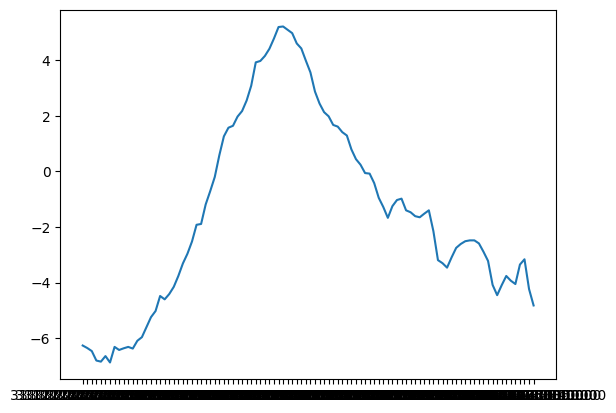

In [18]:
plt.plot(df['T (degC)'][-100:], label='Historical Data')

In [19]:
sequence_length = 6  # Using 6 days of data to predict
# Create and train the model
model = create_model(sequence_length)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
        X_train, y_train,
        # epochs=20,
        epochs=4, # epochs can be reduced to a smaller number like 2 or 5
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1)

Epoch 1/4
3014/3014 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 0.0038 - val_loss: 1.3956e-04
Epoch 2/4
3014/3014 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - loss: 1.6808e-04 - val_loss: 9.0959e-05
Epoch 3/4
3014/3014 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - loss: 7.9727e-05 - val_loss: 3.1618e-05
Epoch 4/4
3014/3014 ━━━━━━━━━━━━━━━━━━━━ 43s 11ms/step - loss: 6.9265e-05 - val_loss: 5.2446e-05


In [21]:
history.history['loss']

[0.0008491395274177194,
 0.0001320322771789506,
 7.678001566091552e-05,
 6.661685620201752e-05]

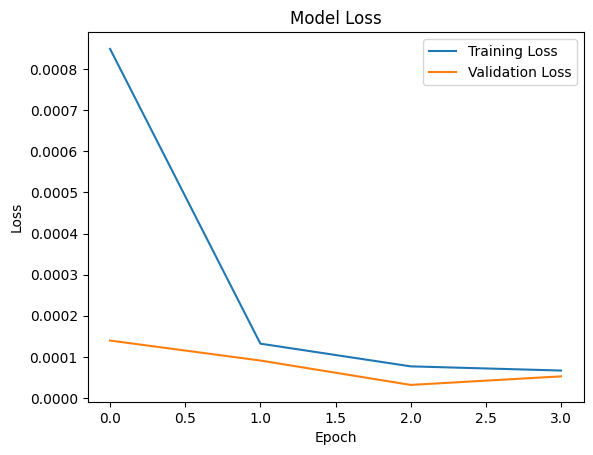

In [22]:
# plot both historical losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [23]:
future_days = 20    # Predicting n times into the future, freq = '10min'

In [24]:
last_sequence = X_test[-1:].copy()  # Using the last actual sequence
predictions = make_future_predictions(model, last_sequence, future_days, scaler)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [25]:
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=future_days+1,freq='10min')[1:]
future_dates

DatetimeIndex(['2017-01-01 00:10:00', '2017-01-01 00:20:00',
               '2017-01-01 00:30:00', '2017-01-01 00:40:00',
               '2017-01-01 00:50:00', '2017-01-01 01:00:00',
               '2017-01-01 01:10:00', '2017-01-01 01:20:00',
               '2017-01-01 01:30:00', '2017-01-01 01:40:00',
               '2017-01-01 01:50:00', '2017-01-01 02:00:00',
               '2017-01-01 02:10:00', '2017-01-01 02:20:00',
               '2017-01-01 02:30:00', '2017-01-01 02:40:00',
               '2017-01-01 02:50:00', '2017-01-01 03:00:00',
               '2017-01-01 03:10:00', '2017-01-01 03:20:00'],
              dtype='datetime64[ns]', freq='10min')

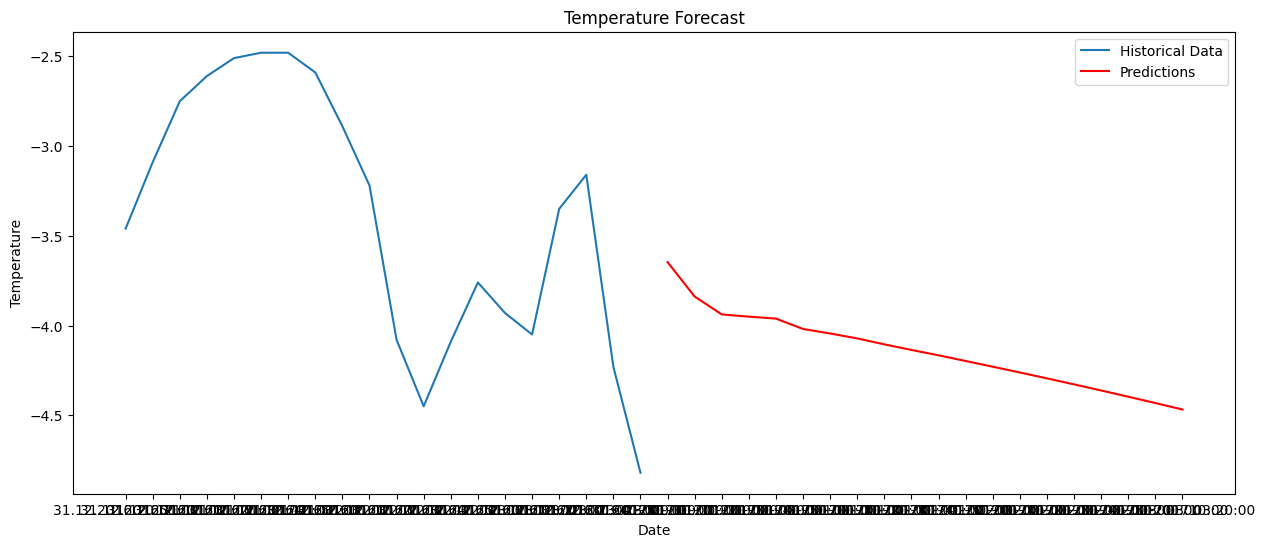

In [26]:
plot_predictions(df, predictions, future_dates)